Wczytywanie danych...
  [OK] Wczytano wyniki_lokalnie_sync.csv jako 'Lokalnie (Sync)'
  [OK] Wczytano wyniki_lokalnie_buffered.csv jako 'Lokalnie (Buffered)'
  [OK] Wczytano wyniki_siec_sync.csv jako 'Sieć (Sync)'
  [OK] Wczytano wyniki_siec_buffered.csv jako 'Sieć (Buffered)'

Generowanie wykresu przepustowości...


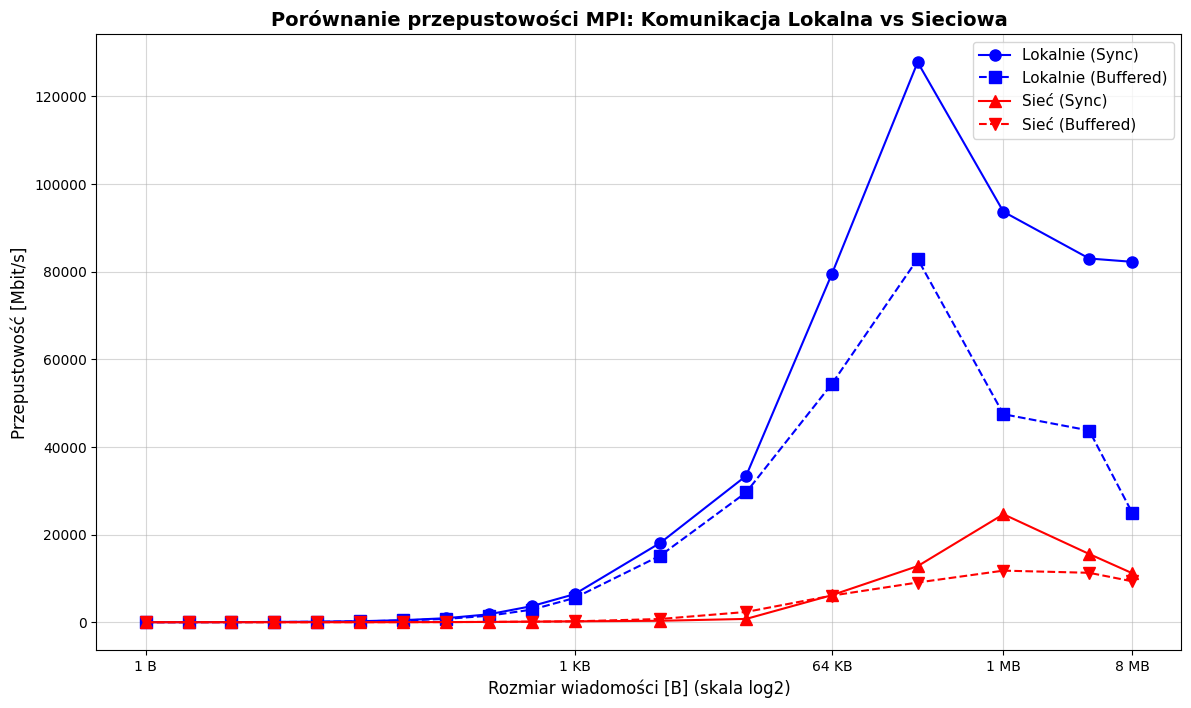

Generowanie wykresu opóźnienia...


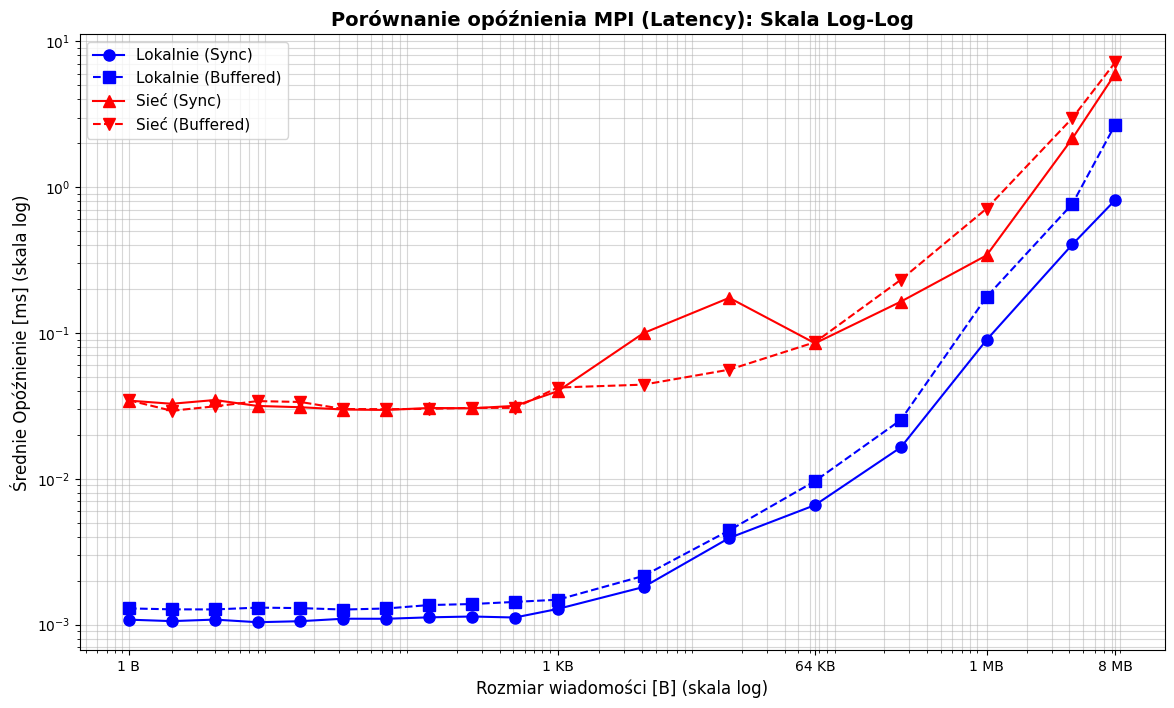


--- Podsumowanie Opóźnienia dla wiadomości 1-bajtowej ---
Lokalnie (Sync)      : 0.001080 ms
Lokalnie (Buffered)  : 0.001290 ms
Sieć (Sync)          : 0.034325 ms
Sieć (Buffered)      : 0.034519 ms


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

data_files = {
    'Lokalnie (Sync)': 'wyniki_lokalnie_sync.csv',
    'Lokalnie (Buffered)': 'wyniki_lokalnie_buffered.csv',
    'Sieć (Sync)': 'wyniki_siec_sync.csv',
    'Sieć (Buffered)': 'wyniki_siec_buffered.csv'
}

dfs = {}

print("Wczytywanie danych...")
for label, filename in data_files.items():
    if os.path.exists(filename):
        dfs[label] = pd.read_csv(filename)
        print(f"  [OK] Wczytano {filename} jako '{label}'")
    else:
        print(f"  [BŁĄD] Nie znaleziono pliku: {filename}")

if not dfs:
    print("Błąd: Nie wczytano żadnych danych. Upewnij się, że pliki CSV istnieją.")
    exit()


print("\nGenerowanie wykresu przepustowości...")
plt.figure(figsize=(14, 8))

styles = {
    'Lokalnie (Sync)': {'color': 'blue', 'marker': 'o', 'linestyle': '-'},
    'Lokalnie (Buffered)': {'color': 'blue', 'marker': 's', 'linestyle': '--'},
    'Sieć (Sync)': {'color': 'red', 'marker': '^', 'linestyle': '-'},
    'Sieć (Buffered)': {'color': 'red', 'marker': 'v', 'linestyle': '--'}
}

for label, df in dfs.items():
    style = styles.get(label, {})
    plt.plot(df['size_bytes'], df['bandwidth_mbit_s'], label=label, **style, markersize=8)

plt.xscale('log', base=2)
plt.xlabel('Rozmiar wiadomości [B] (skala log2)', fontsize=12)
plt.ylabel('Przepustowość [Mbit/s]', fontsize=12)
plt.title('Porównanie przepustowości MPI: Komunikacja Lokalna vs Sieciowa', fontsize=14, fontweight='bold')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(fontsize=11)

ticks_x = [1, 1024, 65536, 1048576, 8388608]
tick_labels = ['1 B', '1 KB', '64 KB', '1 MB', '8 MB']
plt.xticks(ticks_x, tick_labels)

plt.savefig('wykres_bandwidth_porownanie.png', dpi=300)
plt.show()


print("Generowanie wykresu opóźnienia...")
plt.figure(figsize=(14, 8))

for label, df in dfs.items():
    style = styles.get(label, {})
    plt.loglog(df['size_bytes'], df['latency_ms'], label=label, **style, markersize=8)

plt.xlabel('Rozmiar wiadomości [B] (skala log)', fontsize=12)
plt.ylabel('Średnie Opóźnienie [ms] (skala log)', fontsize=12)
plt.title('Porównanie opóźnienia MPI (Latency): Skala Log-Log', fontsize=14, fontweight='bold')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(fontsize=11)

plt.xticks(ticks_x, tick_labels)

plt.savefig('wykres_latency_porownanie.png', dpi=300)
plt.show()


print("\n--- Podsumowanie Opóźnienia dla wiadomości 1-bajtowej ---")
for label, df in dfs.items():
    latency_1b = df.iloc[0]['latency_ms']
    print(f"{label:<20} : {latency_1b:.6f} ms")